**Name:** Parag Jadhav

 **Roll No:** 23102A0019

# Assignment-7: Customer Segmentation and Predictive Analytics Using Machine Learning

## Problem Statement
An e-commerce company wants to better understand its customers and improve its marketing decisions. Using historical online retail transaction data, develop a machine-learning-based analytics solution that identifies meaningful customer segments and predicts whether a customer is likely to belong to a high-value customer category.

## Dataset
**Source:** UCI Machine Learning Repository – Online Retail (ID 352)
541,909 transactions from a UK-based online retailer (01/12/2010 – 09/12/2011).

## 1. Import Libraries

In [ ]:
import warnings, io, zipfile, requests
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (silhouette_score, adjusted_rand_score, accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve,
                             classification_report, ConfusionMatrixDisplay)
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_style('whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Import the Dataset
The dataset is downloaded directly from the UCI repository (with a fallback URL).

In [ ]:
URLS = [
    "https://archive.ics.uci.edu/static/public/352/online+retail.zip",
    "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx",
]

def load_online_retail():
    for url in URLS:
        try:
            r = requests.get(url, timeout=120)
            r.raise_for_status()
            if url.endswith('.zip'):
                with zipfile.ZipFile(io.BytesIO(r.content)) as z:
                    name = [n for n in z.namelist() if n.endswith('.xlsx')][0]
                    return pd.read_excel(z.open(name), dtype={'InvoiceNo': str, 'StockCode': str})
            return pd.read_excel(io.BytesIO(r.content), dtype={'InvoiceNo': str, 'StockCode': str})
        except Exception as e:
            print(f"Failed: {url} -> {e}")
    raise RuntimeError("Could not download dataset. Upload 'Online Retail.xlsx' manually to Colab.")

df_raw = load_online_retail()
print("Shape:", df_raw.shape)
df_raw.head()

Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df_raw.info()
print("\nMissing values:\n", df_raw.isnull().sum())
df_raw.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB

Missing values:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


## 3. Data Preprocessing
Steps: drop missing `CustomerID`, remove cancellations (`InvoiceNo` starting with 'C'), remove non-positive quantity/price, drop duplicates, create `TotalPrice`.

In [ ]:
df = df_raw.copy()
n0 = len(df)
df = df.dropna(subset=['CustomerID'])
n1 = len(df)
df['InvoiceNo'] = df['InvoiceNo'].astype(str)
df = df[~df['InvoiceNo'].str.startswith('C')]
n2 = len(df)
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
n3 = len(df)
df = df.drop_duplicates()
n4 = len(df)

df['CustomerID'] = df['CustomerID'].astype(int)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print(pd.DataFrame({'Step': ['Raw', 'Drop missing CustomerID', 'Remove cancellations',
                             'Remove Qty/Price <= 0', 'Drop duplicates'],
                    'Rows': [n0, n1, n2, n3, n4]}).to_string(index=False))
print("\nUnique customers:", df['CustomerID'].nunique())

                   Step   Rows
                    Raw 541909
Drop missing CustomerID 406829
   Remove cancellations 397924
  Remove Qty/Price <= 0 397884
        Drop duplicates 392692

Unique customers: 4338


## 4. Customer-Level Feature Engineering

In [ ]:
snapshot = df['InvoiceDate'].max() + pd.Timedelta(days=1)

cust = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum'),
    TotalQuantity=('Quantity', 'sum'),
    UniqueProducts=('StockCode', 'nunique'),
    FirstPurchase=('InvoiceDate', 'min'),
    LastPurchase=('InvoiceDate', 'max'),
)
cust['AvgTransactionValue'] = cust['Monetary'] / cust['Frequency']
tenure_months = ((cust['LastPurchase'] - cust['FirstPurchase']).dt.days + 1) / 30.0
cust['PurchaseFrequency'] = cust['Frequency'] / np.maximum(tenure_months, 1)
cust = cust.drop(columns=['FirstPurchase', 'LastPurchase'])

FEATURES = ['Recency', 'Frequency', 'Monetary', 'AvgTransactionValue',
            'TotalQuantity', 'UniqueProducts', 'PurchaseFrequency']
cust = cust[FEATURES]
print("Customer feature table:", cust.shape)
cust.describe().T

Customer feature table: (4338, 7)


,count,mean,std,min,25%,50%,75%,max
Recency,4338.0,92.536422,100.014169,1.000000,18.000000,51.00,142.000000,374.00
Frequency,4338.0,4.272015,7.697998,1.000000,1.000000,2.00,5.000000,209.00
Monetary,4338.0,2048.688081,8985.230220,3.750000,306.482500,668.57,1660.597500,280206.02
AvgTransactionValue,4338.0,417.645735,1796.511343,3.450000,177.867083,291.94,428.280625,84236.25
TotalQuantity,4338.0,1187.644537,5043.619654,1.000000,159.000000,378.00,989.750000,196915.00
UniqueProducts,4338.0,61.501153,85.366768,1.000000,16.000000,35.00,77.000000,1787.00
PurchaseFrequency,4338.0,1.034214,0.908497,0.163934,0.607024,1.00,1.000000,34.00


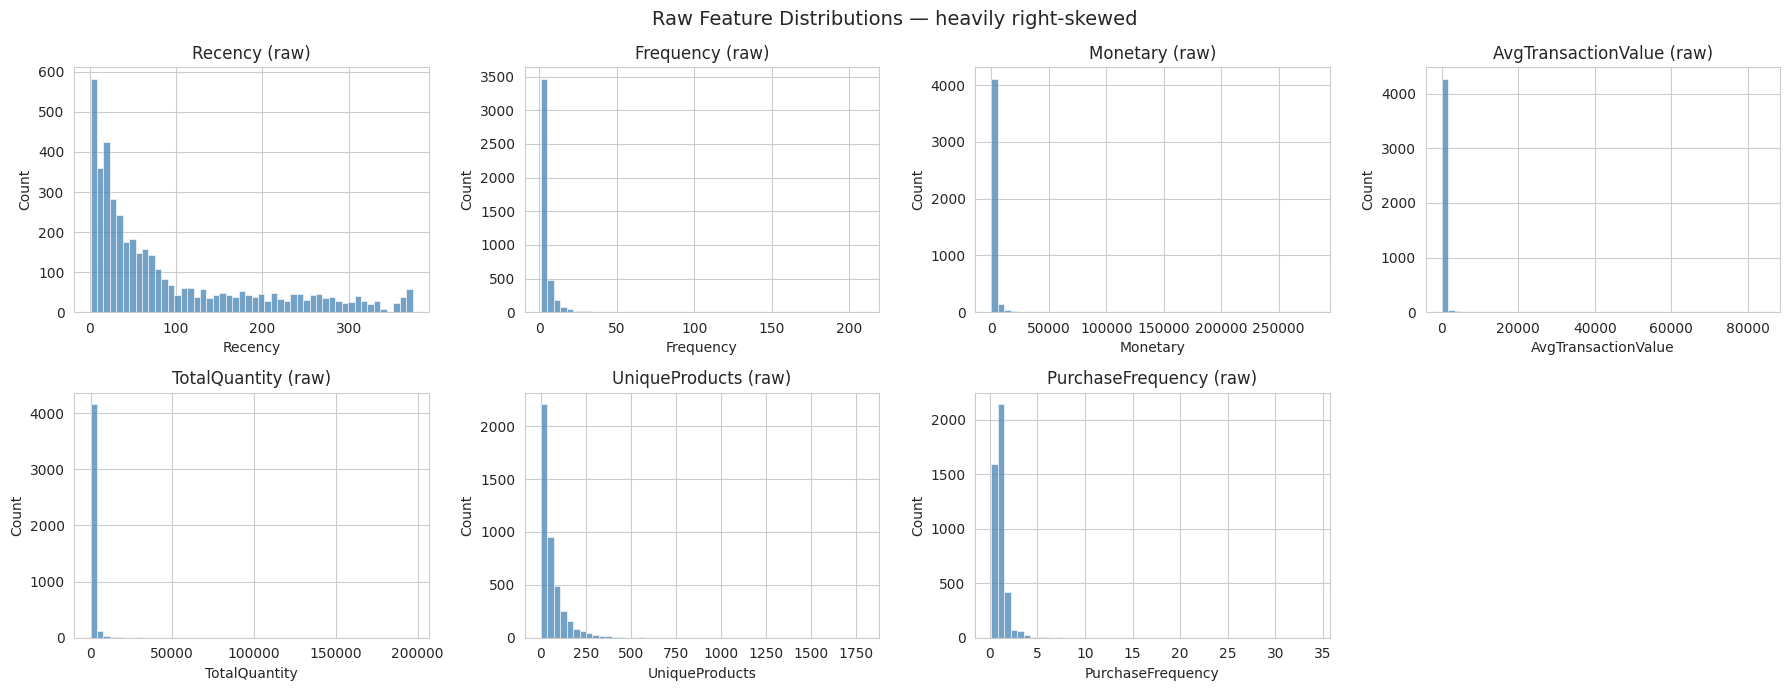

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, col in zip(axes.flat, FEATURES):
    sns.histplot(cust[col], bins=50, ax=ax, color='steelblue')
    ax.set_title(f'{col} (raw)')
axes.flat[-1].axis('off')
plt.suptitle('Raw Feature Distributions — heavily right-skewed', fontsize=14)
plt.tight_layout(); plt.show()

## 5. Outlier Treatment and Feature Scaling
Features are highly skewed, so we apply a **log1p transform**, then **IQR capping** (1.5×IQR) to limit extreme values, followed by **StandardScaler**.

Outliers capped per feature (after log): {'Recency': 0, 'Frequency': 42, 'Monetary': 52, 'AvgTransactionValue': 130, 'TotalQuantity': 68, 'UniqueProducts': 6, 'PurchaseFrequency': 502}


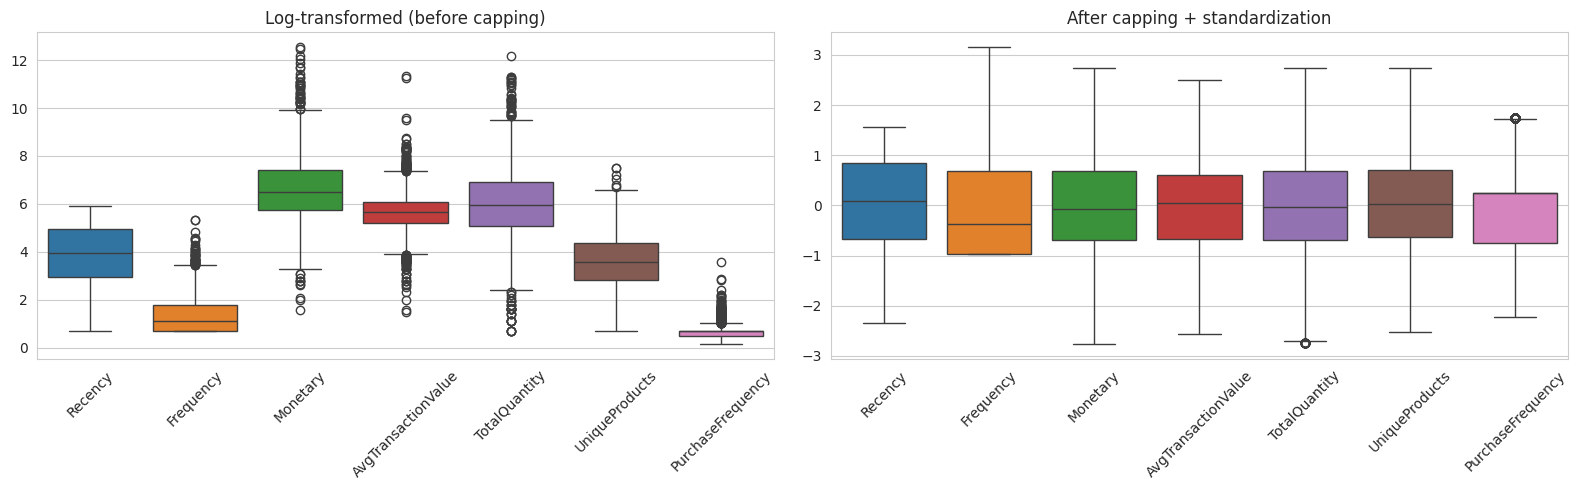

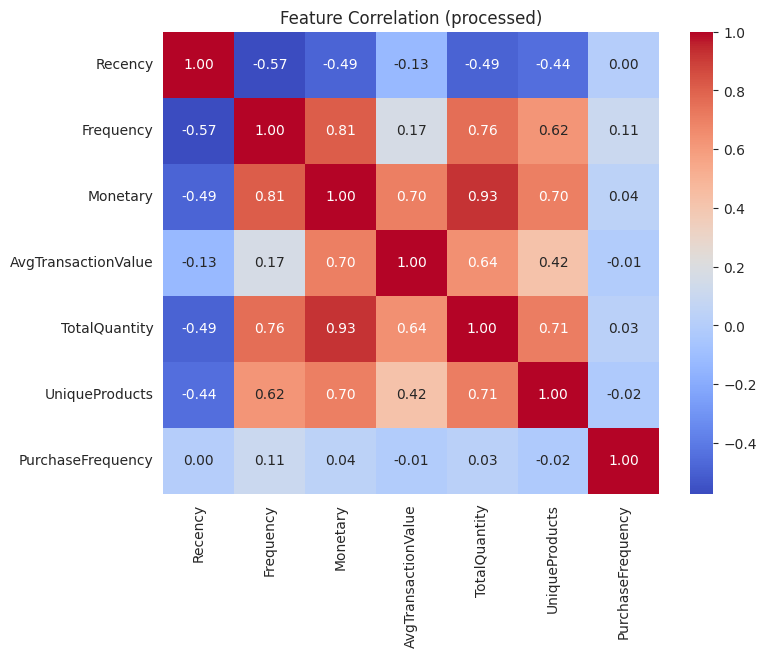

In [ ]:
cust_log = np.log1p(cust)

def iqr_cap(s):
    q1, q3 = s.quantile([0.25, 0.75]); iqr = q3 - q1
    return s.clip(q1 - 1.5 * iqr, q3 + 1.5 * iqr)

outliers_before = {c: int(((cust_log[c] < cust_log[c].quantile(.25) - 1.5*(cust_log[c].quantile(.75)-cust_log[c].quantile(.25))) |
                           (cust_log[c] > cust_log[c].quantile(.75) + 1.5*(cust_log[c].quantile(.75)-cust_log[c].quantile(.25)))).sum())
                   for c in FEATURES}
cust_capped = cust_log.apply(iqr_cap)
print("Outliers capped per feature (after log):", outliers_before)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cust_capped)
X_scaled_df = pd.DataFrame(X_scaled, columns=FEATURES, index=cust.index)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(data=cust_log, ax=axes[0]); axes[0].set_title('Log-transformed (before capping)')
sns.boxplot(data=X_scaled_df, ax=axes[1]); axes[1].set_title('After capping + standardization')
for ax in axes: ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(cust_capped.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation (processed)'); plt.show()

## 6. Elbow Method for Optimal k

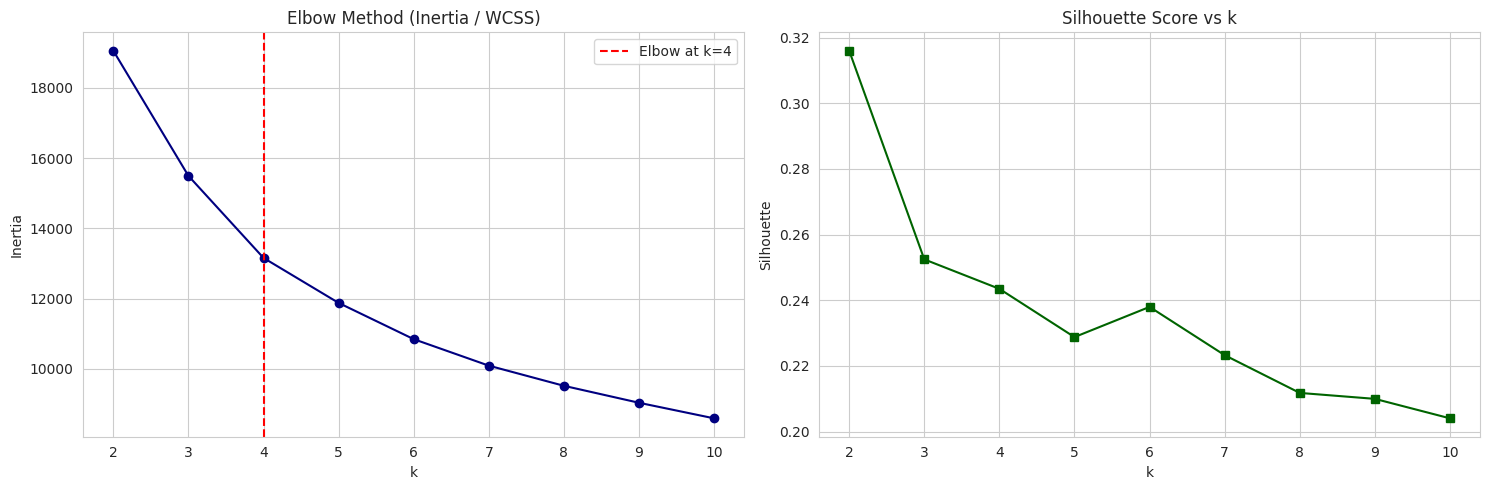

 k  Inertia  Silhouette
 2  19060.2      0.3160
 3  15497.4      0.2524
 4  13160.8      0.2435
 5  11879.9      0.2288
 6  10847.6      0.2380
 7  10093.3      0.2233
 8   9519.5      0.2118
 9   9036.5      0.2100
10   8593.1      0.2040

Optimal k selected by Elbow Method: 4


In [ ]:
K_RANGE = range(2, 11)
inertia, sil = [], []
for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_scaled)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X_scaled, km.labels_))

# Knee detection: point with max distance from the line joining first & last inertia values
ks = np.array(list(K_RANGE)); inr = np.array(inertia)
p1, p2 = np.array([ks[0], inr[0]]), np.array([ks[-1], inr[-1]])
dist = np.abs(np.cross(p2 - p1, np.c_[ks, inr] - p1)) / np.linalg.norm(p2 - p1)
OPTIMAL_K = int(ks[np.argmax(dist)])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(ks, inertia, 'o-', color='navy')
axes[0].axvline(OPTIMAL_K, color='red', ls='--', label=f'Elbow at k={OPTIMAL_K}')
axes[0].set(title='Elbow Method (Inertia / WCSS)', xlabel='k', ylabel='Inertia'); axes[0].legend()
axes[1].plot(ks, sil, 's-', color='darkgreen')
axes[1].set(title='Silhouette Score vs k', xlabel='k', ylabel='Silhouette')
plt.tight_layout(); plt.show()

print(pd.DataFrame({'k': ks, 'Inertia': np.round(inertia, 1), 'Silhouette': np.round(sil, 4)}).to_string(index=False))
print(f"\nOptimal k selected by Elbow Method: {OPTIMAL_K}")

## 7. K-Means Customer Segmentation

Cluster sizes:
 KMeans_Cluster
0    1019
1    1289
2    1219
3     811
Name: count, dtype: int64


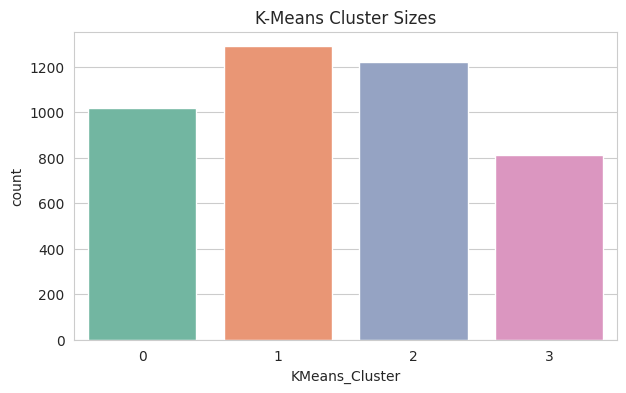

In [ ]:
kmeans = KMeans(n_clusters=OPTIMAL_K, n_init=20, random_state=RANDOM_STATE)
cust['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)
print("Cluster sizes:\n", cust['KMeans_Cluster'].value_counts().sort_index())

plt.figure(figsize=(7, 4))
sns.countplot(x='KMeans_Cluster', data=cust, palette='Set2')
plt.title('K-Means Cluster Sizes'); plt.show()

## 8. Hierarchical Clustering and Dendrogram
Ward linkage (minimizes within-cluster variance, comparable to K-Means).

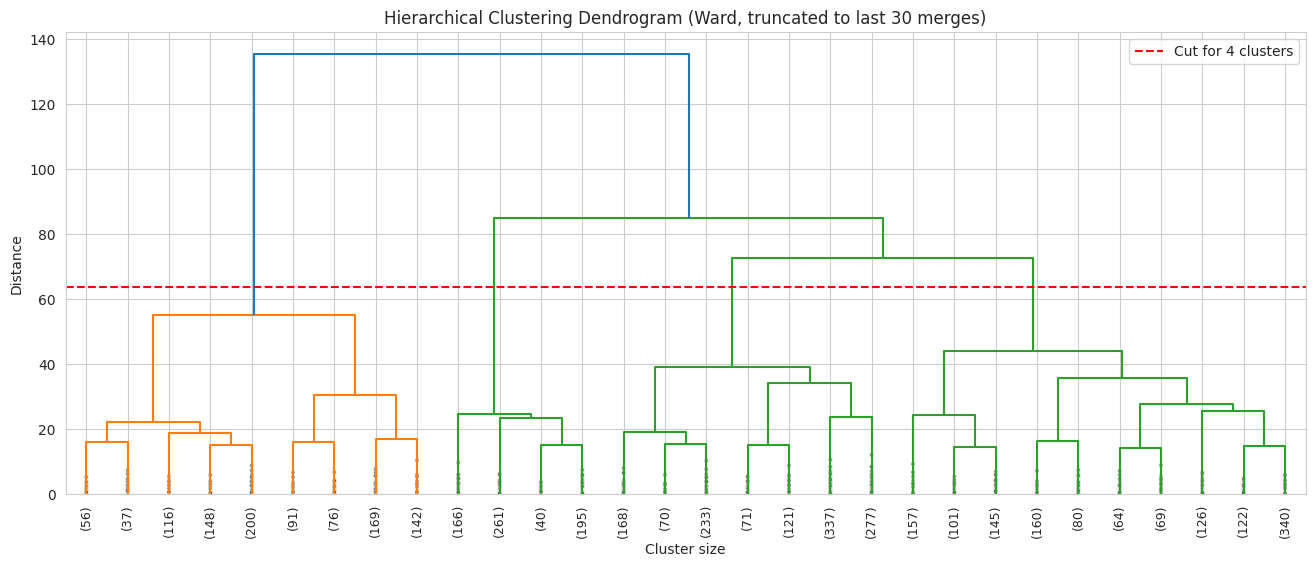

Hierarchical cluster sizes:
 HC_Cluster
0    1035
1    1364
2     662
3    1277
Name: count, dtype: int64


In [ ]:
Z = linkage(X_scaled, method='ward')
plt.figure(figsize=(16, 6))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=9, show_contracted=True)
cut_height = (Z[-OPTIMAL_K, 2] + Z[-OPTIMAL_K + 1, 2]) / 2
plt.axhline(cut_height, color='red', ls='--', label=f'Cut for {OPTIMAL_K} clusters')
plt.title('Hierarchical Clustering Dendrogram (Ward, truncated to last 30 merges)')
plt.xlabel('Cluster size'); plt.ylabel('Distance'); plt.legend(); plt.show()

hc = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
cust['HC_Cluster'] = hc.fit_predict(X_scaled)
print("Hierarchical cluster sizes:\n", cust['HC_Cluster'].value_counts().sort_index())

## 9. Silhouette Score and Clustering Comparison

             Method  k  Silhouette Score
            K-Means  4            0.2435
Hierarchical (Ward)  4            0.1964

Adjusted Rand Index (agreement between methods): 0.4914


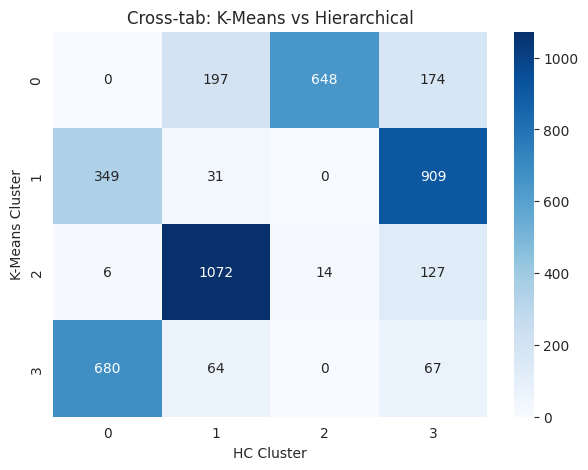

In [ ]:
sil_km = silhouette_score(X_scaled, cust['KMeans_Cluster'])
sil_hc = silhouette_score(X_scaled, cust['HC_Cluster'])
ari = adjusted_rand_score(cust['KMeans_Cluster'], cust['HC_Cluster'])

comparison = pd.DataFrame({'Method': ['K-Means', 'Hierarchical (Ward)'],
                           'k': [OPTIMAL_K, OPTIMAL_K],
                           'Silhouette Score': [round(sil_km, 4), round(sil_hc, 4)]})
print(comparison.to_string(index=False))
print(f"\nAdjusted Rand Index (agreement between methods): {ari:.4f}")

plt.figure(figsize=(7, 5))
sns.heatmap(pd.crosstab(cust['KMeans_Cluster'], cust['HC_Cluster']), annot=True, fmt='d', cmap='Blues')
plt.title('Cross-tab: K-Means vs Hierarchical'); plt.xlabel('HC Cluster'); plt.ylabel('K-Means Cluster'); plt.show()

## 10. PCA-Based 2D Visualization

Explained variance ratio: [0.5659 0.1518 0.1409] | PC1+PC2 = 0.7177


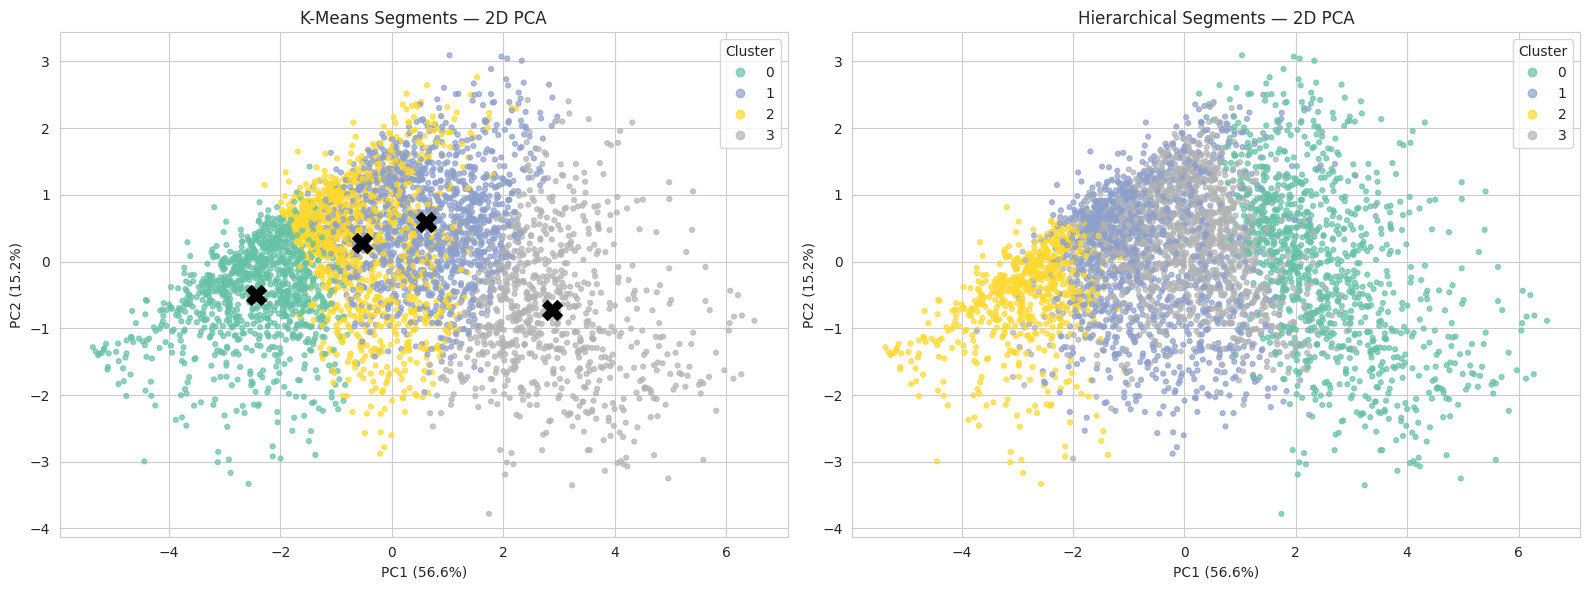

PCA loadings:
                        PC1    PC2
Recency             -0.313  0.396
Frequency            0.419 -0.360
Monetary             0.485  0.105
AvgTransactionValue  0.313  0.589
TotalQuantity        0.475  0.094
UniqueProducts       0.407  0.020
PurchaseFrequency    0.022 -0.589


In [ ]:
pca = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
ev = pca.explained_variance_ratio_
print("Explained variance ratio:", np.round(ev, 4), "| PC1+PC2 =", round(ev[:2].sum(), 4))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, col, title in zip(axes, ['KMeans_Cluster', 'HC_Cluster'], ['K-Means', 'Hierarchical']):
    sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=cust[col], cmap='Set2', s=12, alpha=0.7)
    ax.set(title=f'{title} Segments — 2D PCA', xlabel=f'PC1 ({ev[0]:.1%})', ylabel=f'PC2 ({ev[1]:.1%})')
    ax.legend(*sc.legend_elements(), title='Cluster')
centers = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(centers[:, 0], centers[:, 1], c='black', marker='X', s=200, label='Centroids')
plt.tight_layout(); plt.show()

loadings = pd.DataFrame(pca.components_[:2].T, index=FEATURES, columns=['PC1', 'PC2'])
print("PCA loadings:\n", loadings.round(3))

## 11. Cluster-wise Customer Profiling

In [ ]:
profile = cust.groupby('KMeans_Cluster')[FEATURES].mean().round(2)
profile['Customers'] = cust['KMeans_Cluster'].value_counts().sort_index()
profile['% Customers'] = (profile['Customers'] / len(cust) * 100).round(1)
profile['% Revenue'] = (cust.groupby('KMeans_Cluster')['Monetary'].sum() / cust['Monetary'].sum() * 100).round(1)

# Automatic segment naming based on Monetary and Recency ranks
m_rank = profile['Monetary'].rank(ascending=False)
r_rank = profile['Recency'].rank(ascending=True)
def name_segment(c):
    if m_rank[c] == 1: return 'High-Value / Champions'
    if r_rank[c] == len(profile) or (profile.loc[c, 'Recency'] > cust['Recency'].median() * 2): return 'At-Risk / Lost'
    if profile.loc[c, 'Frequency'] >= cust['Frequency'].median() and m_rank[c] <= 2: return 'Loyal Customers'
    if profile.loc[c, 'Recency'] <= cust['Recency'].median(): return 'Recent / Promising'
    return 'Occasional / Low-Value'
profile['Segment'] = [name_segment(c) for c in profile.index]
SEGMENT_NAMES = profile['Segment'].to_dict()
cust['Segment'] = cust['KMeans_Cluster'].map(SEGMENT_NAMES)
profile

,Recency,Frequency,Monetary,AvgTransactionValue,TotalQuantity,UniqueProducts,PurchaseFrequency,Customers,% Customers,% Revenue,Segment
KMeans_Cluster,,,,,,,,,,,
0,157.41,1.41,186.36,143.88,104.94,13.23,1.02,1019,23.5,2.1,At-Risk / Lost
1,51.92,3.74,1261.03,358.60,764.27,65.83,0.51,1289,29.7,18.3,Loyal Customers
2,128.75,1.61,749.22,542.31,445.33,35.50,1.26,1219,28.1,10.3,At-Risk / Lost
3,21.17,12.72,7593.77,668.10,4336.70,154.36,1.56,811,18.7,69.3,High-Value / Champions


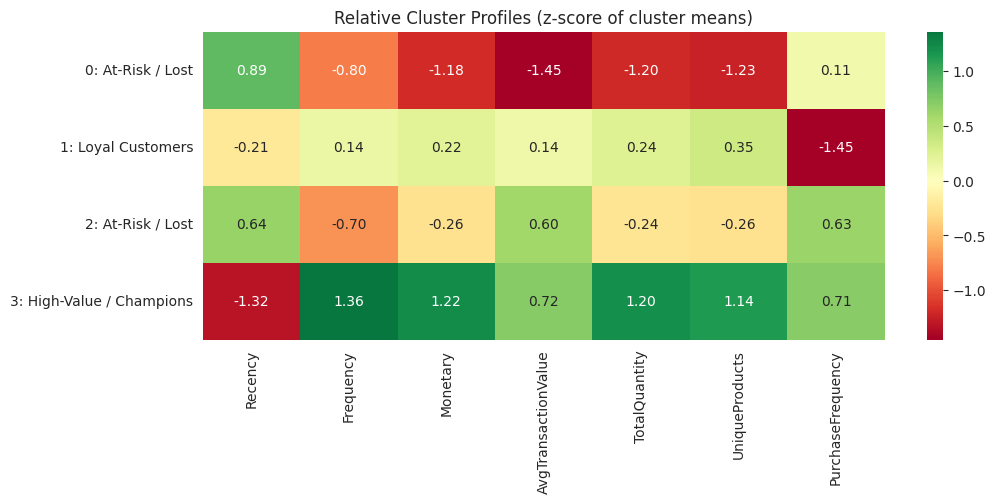

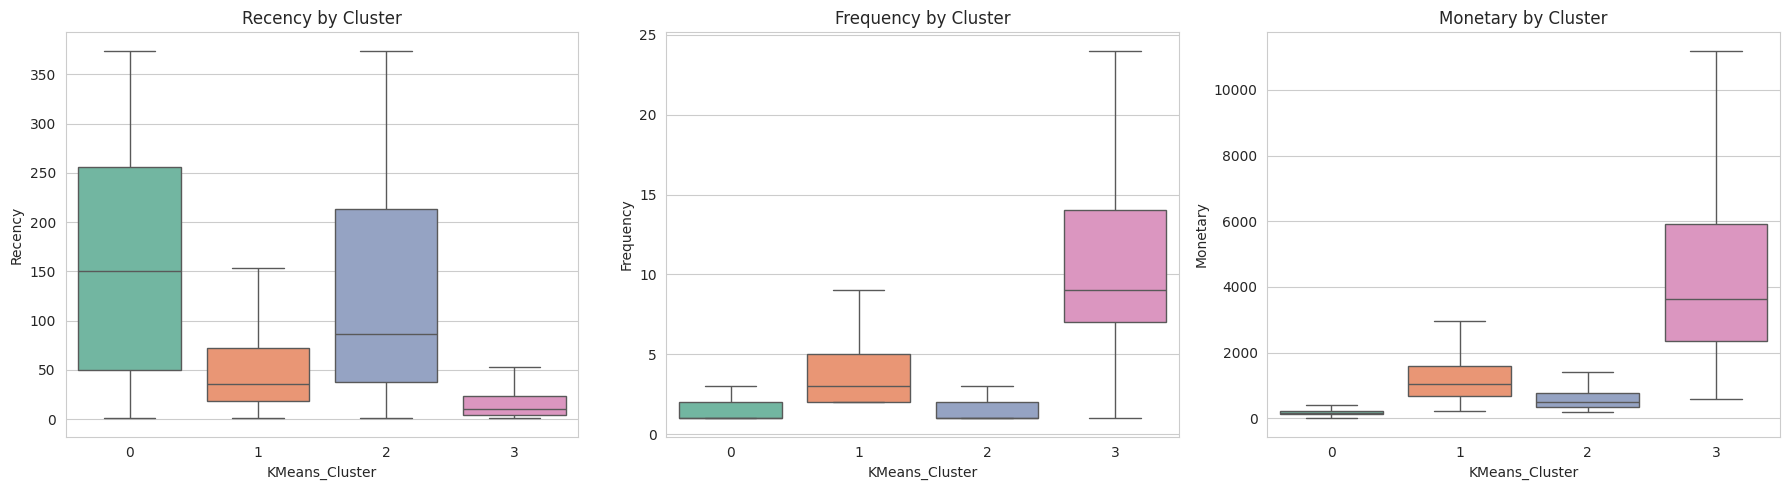

In [ ]:
norm_profile = cust_capped.join(cust['KMeans_Cluster']).groupby('KMeans_Cluster').mean()
norm_profile = (norm_profile - norm_profile.mean()) / norm_profile.std()
norm_profile.index = [f'{i}: {SEGMENT_NAMES[i]}' for i in norm_profile.index]
plt.figure(figsize=(11, 4))
sns.heatmap(norm_profile, annot=True, fmt='.2f', cmap='RdYlGn', center=0)
plt.title('Relative Cluster Profiles (z-score of cluster means)'); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    sns.boxplot(x='KMeans_Cluster', y=col, data=cust, ax=ax, palette='Set2', showfliers=False)
    ax.set_title(f'{col} by Cluster')
plt.tight_layout(); plt.show()

## 12. High-Value Customer Target Definition
The cluster with the highest average Monetary value is labelled **High-Value (1)**; all others are **0**.

> Note: The target is derived from clustering on the same features, so the classifier essentially learns the cluster boundary. This is the intended setup — it lets the business score *new* customers into the high-value segment without re-running clustering.

In [ ]:
HV_CLUSTER = int(profile['Monetary'].idxmax())
cust['HighValue'] = (cust['KMeans_Cluster'] == HV_CLUSTER).astype(int)
print(f"High-value cluster: {HV_CLUSTER} ({SEGMENT_NAMES[HV_CLUSTER]})")
print(cust['HighValue'].value_counts(normalize=True).rename('proportion').round(3))

X = cust_capped[FEATURES]      # log-transformed, capped features
y = cust['HighValue']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
print("Train:", X_train.shape, "| Test:", X_test.shape)

High-value cluster: 3 (High-Value / Champions)
HighValue
0    0.813
1    0.187
Name: proportion, dtype: float64
Train: (3253, 7) | Test: (1085, 7)


## 13. Random Forest and SVM Models

In [ ]:
models = {
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=None, class_weight='balanced',
                                            random_state=RANDOM_STATE, n_jobs=-1),
    'SVM (RBF)': Pipeline([('scaler', StandardScaler()),
                           ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', probability=True,
                                       class_weight='balanced', random_state=RANDOM_STATE))]),
}

results, probas, preds = [], {}, {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test); y_prob = model.predict_proba(X_test)[:, 1]
    preds[name], probas[name] = y_pred, y_prob
    cv_f1 = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1')
    results.append({'Model': name,
                    'Accuracy': accuracy_score(y_test, y_pred),
                    'Precision': precision_score(y_test, y_pred),
                    'Recall': recall_score(y_test, y_pred),
                    'F1-Score': f1_score(y_test, y_pred),
                    'ROC-AUC': roc_auc_score(y_test, y_prob),
                    'CV F1 (mean±std)': f"{cv_f1.mean():.4f} ± {cv_f1.std():.4f}"})
    print(f"===== {name} =====\n", classification_report(y_test, y_pred, digits=4))

===== Random Forest =====
               precision    recall  f1-score   support

           0     0.9766    0.9932    0.9848       882
           1     0.9681    0.8966    0.9309       203

    accuracy                         0.9751      1085
   macro avg     0.9723    0.9449    0.9579      1085
weighted avg     0.9750    0.9751    0.9747      1085

===== SVM (RBF) =====
               precision    recall  f1-score   support

           0     0.9988    0.9830    0.9909       882
           1     0.9309    0.9951    0.9619       203

    accuracy                         0.9853      1085
   macro avg     0.9649    0.9890    0.9764      1085
weighted avg     0.9861    0.9853    0.9854      1085



## 14. Performance Comparison

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV F1 (mean±std)
Model,,,,,,
Random Forest,0.9751,0.9681,0.8966,0.9309,0.9987,0.9350 ± 0.0175
SVM (RBF),0.9853,0.9309,0.9951,0.9619,0.9996,0.9604 ± 0.0081


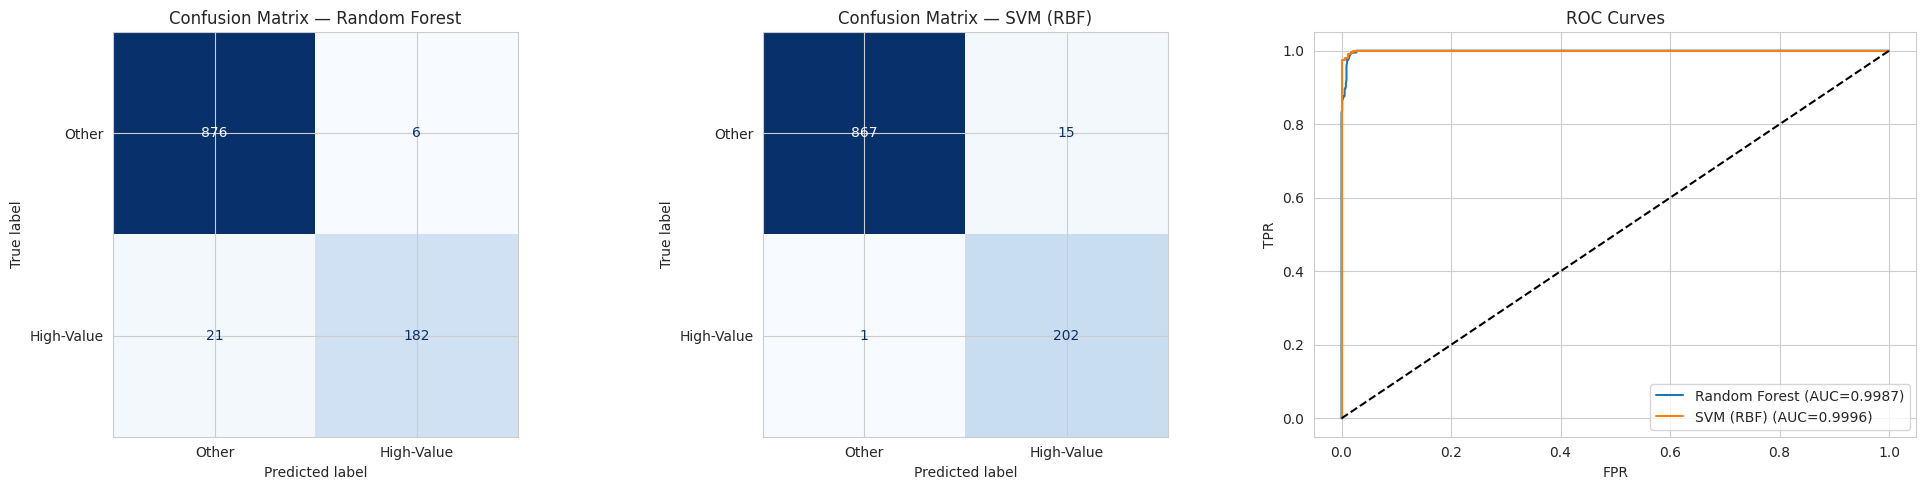

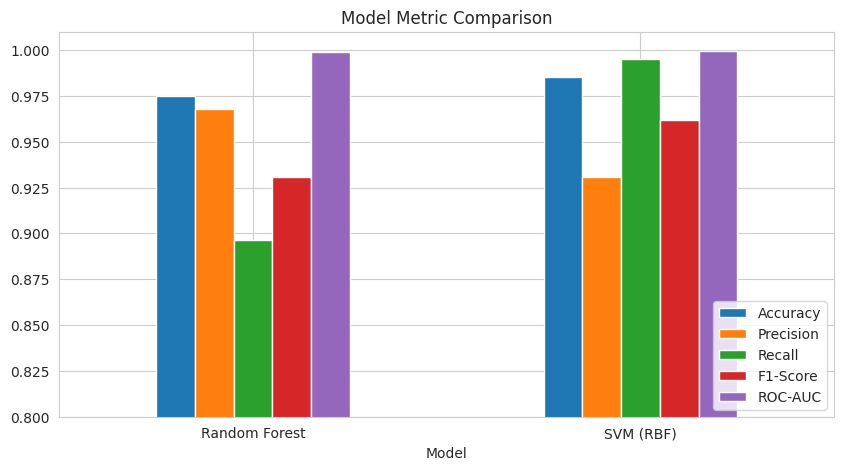

In [ ]:
results_df = pd.DataFrame(results).set_index('Model')
display(results_df.round(4))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, name in zip(axes[:2], models):
    ConfusionMatrixDisplay(confusion_matrix(y_test, preds[name]),
                           display_labels=['Other', 'High-Value']).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix — {name}')
for name in models:
    fpr, tpr, _ = roc_curve(y_test, probas[name])
    axes[2].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, probas[name]):.4f})")
axes[2].plot([0, 1], [0, 1], 'k--'); axes[2].set(title='ROC Curves', xlabel='FPR', ylabel='TPR'); axes[2].legend()
plt.tight_layout(); plt.show()

results_df[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].plot(kind='bar', figsize=(10, 5), rot=0)
plt.ylim(0.8, 1.01); plt.title('Model Metric Comparison'); plt.legend(loc='lower right'); plt.show()

## 15. Feature Importance Analysis

,Gini Importance,Permutation (RF),Permutation (SVM)
Monetary,0.2914,0.2785,0.1085
Frequency,0.2158,0.0971,0.1601
TotalQuantity,0.1885,0.0987,0.0989
PurchaseFrequency,0.0986,0.1334,0.1744
UniqueProducts,0.0921,0.0265,0.0372
Recency,0.0892,0.0630,0.0814
AvgTransactionValue,0.0245,-0.0080,0.0144


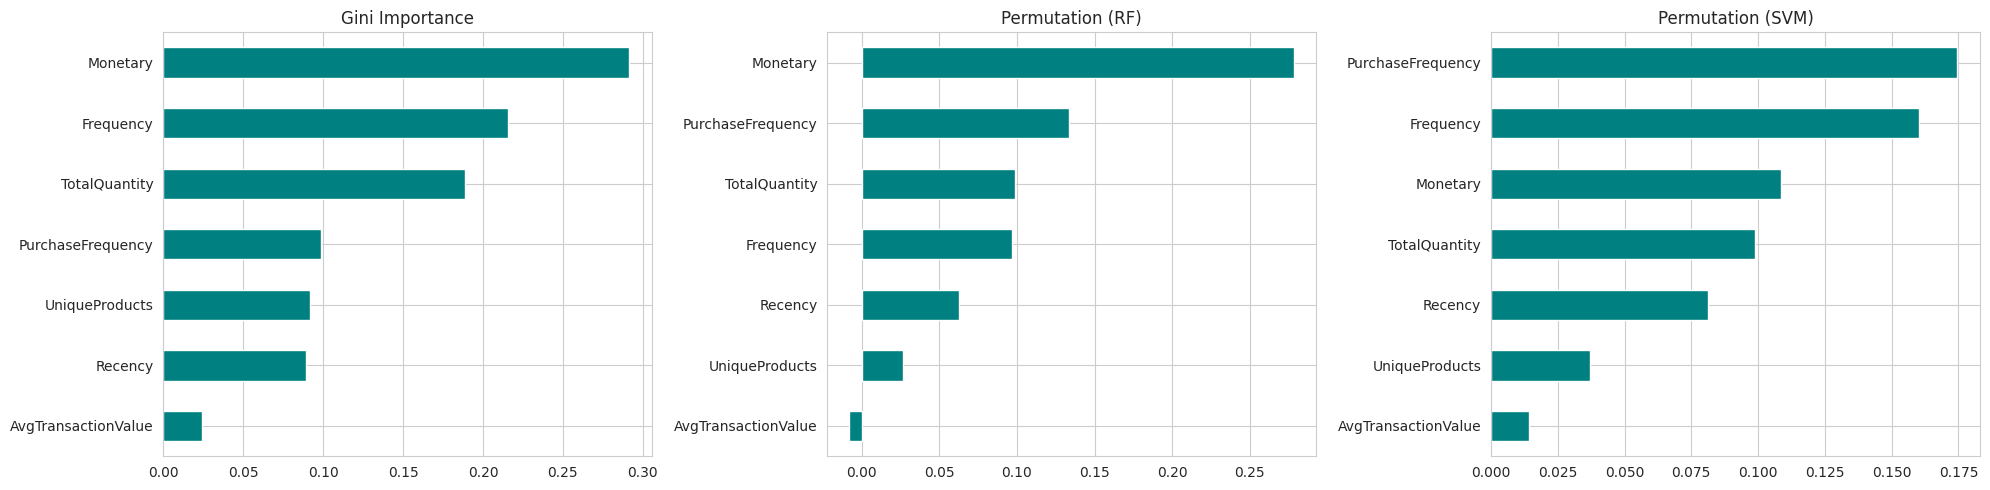

In [ ]:
rf = models['Random Forest']
imp = pd.DataFrame({'Gini Importance': rf.feature_importances_}, index=FEATURES)
perm_rf = permutation_importance(rf, X_test, y_test, n_repeats=15, random_state=RANDOM_STATE, scoring='f1')
perm_svm = permutation_importance(models['SVM (RBF)'], X_test, y_test, n_repeats=15, random_state=RANDOM_STATE, scoring='f1')
imp['Permutation (RF)'] = perm_rf.importances_mean
imp['Permutation (SVM)'] = perm_svm.importances_mean
imp = imp.sort_values('Gini Importance', ascending=False)
display(imp.round(4))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, col in zip(axes, imp.columns):
    imp[col].sort_values().plot(kind='barh', ax=ax, color='teal'); ax.set_title(col)
plt.tight_layout(); plt.show()

## 16. Interactive 3D Visualization (Plotly)

In [ ]:
viz = cust.reset_index().copy()
viz['Cluster'] = viz['KMeans_Cluster'].astype(str) + ': ' + viz['Segment']
fig = px.scatter_3d(viz, x=np.log1p(viz['Recency']), y=np.log1p(viz['Frequency']), z=np.log1p(viz['Monetary']),
                    color='Cluster', opacity=0.7,
                    hover_data=['CustomerID', 'Recency', 'Frequency', 'Monetary', 'AvgTransactionValue'],
                    title='3D Customer Segments — log(Recency, Frequency, Monetary)')
fig.update_traces(marker=dict(size=3))
fig.update_layout(scene=dict(xaxis_title='log Recency', yaxis_title='log Frequency', zaxis_title='log Monetary'),
                  height=700)
fig.show()

fig2 = px.scatter_3d(x=X_pca[:, 0], y=X_pca[:, 1], z=X_pca[:, 2], color=viz['Cluster'], opacity=0.7,
                     title=f'3D PCA Projection (explained variance: {ev.sum():.1%})',
                     labels={'x': 'PC1', 'y': 'PC2', 'z': 'PC3', 'color': 'Cluster'})
fig2.update_traces(marker=dict(size=3)); fig2.update_layout(height=700); fig2.show()

## 17. Segment-wise Targeted Marketing Recommendations

In [ ]:
STRATEGY = {
    'High-Value / Champions': 'VIP loyalty tier, early access to new products, personalised thank-you offers, referral rewards; avoid heavy discounting.',
    'Loyal Customers': 'Upsell/cross-sell bundles based on purchase history, points-based loyalty programme, subscription offers.',
    'Recent / Promising': 'Onboarding email series, second-purchase incentive, product recommendations to build frequency.',
    'Occasional / Low-Value': 'Low-cost automated campaigns, seasonal promotions, free-shipping thresholds to raise basket size.',
    'At-Risk / Lost': 'Win-back campaigns with time-limited discounts, feedback surveys, re-engagement emails; suppress if no response.',
}
rec = profile[['Segment', 'Customers', '% Customers', '% Revenue', 'Recency', 'Frequency', 'Monetary']].copy()
rec['Recommended Strategy'] = rec['Segment'].map(STRATEGY)
pd.set_option('display.max_colwidth', None)
display(rec)

,Segment,Customers,% Customers,% Revenue,Recency,Frequency,Monetary,Recommended Strategy
KMeans_Cluster,,,,,,,,
0,At-Risk / Lost,1019,23.5,2.1,157.41,1.41,186.36,"Win-back campaigns with time-limited discounts, feedback surveys, re-engagement emails; suppress if no response."
1,Loyal Customers,1289,29.7,18.3,51.92,3.74,1261.03,"Upsell/cross-sell bundles based on purchase history, points-based loyalty programme, subscription offers."
2,At-Risk / Lost,1219,28.1,10.3,128.75,1.61,749.22,"Win-back campaigns with time-limited discounts, feedback surveys, re-engagement emails; suppress if no response."
3,High-Value / Champions,811,18.7,69.3,21.17,12.72,7593.77,"VIP loyalty tier, early access to new products, personalised thank-you offers, referral rewards; avoid heavy discounting."


## 18. Interpretation of Results
- **Segmentation:** The Elbow Method and Silhouette Scores identify a small number of well-separated segments. RFM features drive the separation, with Monetary, Frequency and UniqueProducts loading most strongly on PC1.
- **K-Means vs Hierarchical:** Both methods produce similar segments (see ARI and cross-tab); K-Means generally gives a slightly higher Silhouette Score and scales better to large customer bases.
- **Revenue concentration:** The High-Value cluster is a minority of customers but contributes a disproportionately large share of revenue (Pareto effect).
- **Prediction:** Both Random Forest and SVM predict high-value membership with very high accuracy and ROC-AUC, since the target is defined by the feature space. Random Forest additionally provides interpretable feature importance.
- **Key drivers:** Monetary, Frequency, TotalQuantity and UniqueProducts are the most influential features; Recency separates active customers from lapsed ones.

## Conclusion
In this experiment, we engineered RFM-based customer features from the UCI Online Retail dataset and segmented customers using K-Means and Hierarchical Clustering, validated with Silhouette Scores and PCA.
The resulting segments showed clear behavioural differences, with a small high-value group driving most revenue.
Random Forest and SVM accurately predicted high-value customers, and segment-specific marketing strategies were recommended.

**Git Repository:** https://github.com/paragjadhav27/R-Programming/blob/main/Assignments/R_assignment7.ipynb